# Surena × LIBERO Environment

## 1. Setup

In [1]:
# Imports, paths, and global runtime setup
from __future__ import annotations

import os, sys, time, gc, math, traceback
from pathlib import Path

# Project paths (override with environment variables when needed)
SURENA_WORKSPACE = Path(os.environ.get("SURENA_WORKSPACE", Path.home())).expanduser().resolve()
SURENA_REPO_ROOT = Path(os.environ.get(
    "SURENA_VLA_PROJECT_ROOT", SURENA_WORKSPACE / "surena-vla-manipulation"
)).expanduser().resolve()
OPENVLA_ROOT = Path(os.environ.get(
    "OPENVLA_ROOT", SURENA_WORKSPACE / "openvla-mini"
)).expanduser().resolve()
LIBERO_DIR = Path(os.environ.get(
    "LIBERO_ROOT", SURENA_WORKSPACE / "LIBERO"
)).expanduser().resolve()

# VLA checkpoints
CHECKPOINT_ROOT = Path(os.environ.get(
    "SURENA_VLA_CHECKPOINT_ROOT",
    "/media/parsa/OS/Users/parsa/Desktop/vla/checkpoints",
)).expanduser().resolve()

VLA_CHECKPOINT_PLAIN = (
    CHECKPOINT_ROOT / "minivla-libero90/checkpoints/step-122500-epoch-55-loss=0.0743.pt"
)
VLA_CHECKPOINT_VQ = (
    CHECKPOINT_ROOT / "minivla-libero90-vq/checkpoints/step-150000-epoch-67-loss=0.0934.pt"
)

VLA_CHECKPOINT = VLA_CHECKPOINT_PLAIN
# VLA_CHECKPOINT = VLA_CHECKPOINT_VQ

VLA_UNNORM_KEY = "libero_90"

# VQ tokenizer folder
VQ_NAME = "pretrain_vq+mx-libero_90+fach-7+ng-7+nemb-128+nlatent-512"
VQ_DIR  = OPENVLA_ROOT / "vq" / VQ_NAME
REQUIRE_VQ_FILES = bool(VLA_CHECKPOINT == VLA_CHECKPOINT_VQ)

# Default Surena/VLA bridge parameters
IK_MAX_REACH = 0.70
HONEST_STICKY_ATTACH_DISTANCE = 0.07

# Environment variables
os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("PRISMATIC_DATA_ROOT", "/tmp/prismatic_data")
os.environ.setdefault("HF_HOME", str(Path(os.environ.get("SURENA_VLA_HF_HOME", "/media/parsa/OS/Users/parsa/Desktop/vla/hf_cache")).expanduser()))

# Avoid TensorFlow/JAX side imports from transformers/prismatic.
os.environ.setdefault("USE_TF", "0")
os.environ.setdefault("USE_FLAX", "0")
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# All three repositories are installed in editable mode; no sys.path mutation is needed.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from PIL import Image

import mujoco
import mink

import importlib

from surena_vla.control import (
    SurenaArmController,
    StickyGripper,
    HOME_QPOS,
    DEG,
    MAX_REACH,
    ARM_INDICES,
    GAZEBO_INDEX_MAP_BARE,
    clamp_joints,
    get_loop_params,
    render_frame,
    reset_settle_rebind,
    execute_joint_target,
    make_rgb_animation,
    save_episode_video,
)
from surena_vla.paths import VIDEOS_ROOT

plt.rcParams["animation.embed_limit"] = 80  # MB
print("Imports OK")

Imports OK


## 2. Load VLA model

In [2]:
# Load VLA model  (GPU, run once)

import torch
import psutil
from prismatic.models.load import load_vla

if REQUIRE_VQ_FILES:
    os.chdir(OPENVLA_ROOT)

_orig_torch_load = torch.load
def _patched_torch_load(f, map_location=None, **kwargs):
    if map_location is None:
        map_location = "cpu"
    kwargs.setdefault("weights_only", False)
    return _orig_torch_load(f, map_location=map_location, **kwargs)

torch.load = _patched_torch_load

print(f"RAM free:  {psutil.virtual_memory().available / 1e9:.1f} GB")
if torch.cuda.is_available():
    free_vram, total_vram = torch.cuda.mem_get_info()
    print(f"GPU:       {torch.cuda.get_device_name(0)}")
    print(f"VRAM free: {free_vram / 1e9:.2f} / {total_vram / 1e9:.2f} GB")
else:
    raise RuntimeError("CUDA is not available. This notebook expects GPU inference.")

gc.collect()
torch.cuda.empty_cache()

t0 = time.time()
print("Loading VLA...")

vla = load_vla(VLA_CHECKPOINT, hf_token=None, load_for_training=False)
vla = vla.to("cuda", dtype=torch.float16).eval()
vla.enable_mixed_precision_training = False

gc.collect()
torch.cuda.empty_cache()

print(f"Loaded in {time.time() - t0:.1f} s")
print(f"VRAM used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

RAM free:  11.1 GB
GPU:       NVIDIA GeForce GTX 1660 Ti with Max-Q Design
VRAM free: 6.08 / 6.23 GB
Loading VLA...


07/13 [16:05:36] INFO     | >> [*] Loading from local checkpoint path                                   ]8;id=5669424;file:///home/parsa/surena-vla-ws/openvla-mini/prismatic/models/load.py\load.py]8;;\:]8;id=5669425;file:///home/parsa/surena-vla-ws/openvla-mini/prismatic/models/load.py#144\144]8;;\
                          `/media/parsa/OS/Users/parsa/Desktop/vla/checkpoints/minivla-libero90/checkpo            
                          ints/step-122500-epoch-55-loss=0.0743.pt`                                                

                 INFO     | >> [*] Base vlm: prism-qwen25-extra-dinosiglip-224px+0_5b                   ]8;id=5669431;file:///home/parsa/surena-vla-ws/openvla-mini/prismatic/models/load.py\load.py]8;;\:]8;id=5669432;file:///home/parsa/surena-vla-ws/openvla-mini/prismatic/models/load.py#196\196]8;;\

                 INFO     | >> [*] Found Config =>> Loading & Freezing                                  ]8;id=5669438;file:///home/parsa/surena-vla-ws/openvla-mini/prismatic/models/load.py\load.py]8;;\:]8;id=5669439;file:///home/parsa/surena-vla-ws/openvla-mini/prismatic/models/load.py#205\205]8;;\
                          prism-qwen25-extra-dinosiglip-224px+0_5b with:                                           
                                       Vision Backbone =>> dinosiglip-vit-so-224px                                 
                                       LLM Backbone    =>> qwen25-0_5b-extra                                       
                                       Arch Specifier  =>> no-align+fused-gelu-mlp                                 
                                       Checkpoint Path =>>                                                         
                          `/media/parsa/OS/Users/parsa/Desktop/vla/checkpoints/minivla-libero90/checkpo            
                          ints/step-122500-epoch-55-loss=0.0743.pt`                                                

                 INFO     | >> [*] Loading Vision Backbone dinosiglip-vit-so-224px                      ]8;id=5669445;file:///home/parsa/surena-vla-ws/openvla-mini/prismatic/models/load.py\load.py]8;;\:]8;id=5669446;file:///home/parsa/surena-vla-ws/openvla-mini/prismatic/models/load.py#220\220]8;;\

...

                 INFO     | >>     |=> Building empty qwen2.5 LLM from `Qwen/Qwen2.5-0.5B`          ]8;id=5669460;file:///home/parsa/surena-vla-ws/openvla-mini/prismatic/models/backbones/llm/base_llm.py\base_llm.py]8;;\:]8;id=5669461;file:///home/parsa/surena-vla-ws/openvla-mini/prismatic/models/backbones/llm/base_llm.py#134\134]8;;\

07/13 [16:06:06] INFO     | >>     |=> Loading qwen2.5 (Fast) Tokenizer via the AutoTokenizer API   ]8;id=5669467;file:///home/parsa/surena-vla-ws/openvla-mini/prismatic/models/backbones/llm/base_llm.py\base_llm.py]8;;\:]8;id=5669468;file:///home/parsa/surena-vla-ws/openvla-mini/prismatic/models/backbones/llm/base_llm.py#156\156]8;;\

Added 256 extra tokens.


07/13 [16:06:07] INFO     | >> [*] Loading VLA prism-qwen25-extra-dinosiglip-224px+0_5b from Checkpoint ]8;id=5669474;file:///home/parsa/surena-vla-ws/openvla-mini/prismatic/models/load.py\load.py]8;;\:]8;id=5669475;file:///home/parsa/surena-vla-ws/openvla-mini/prismatic/models/load.py#241\241]8;;\

Loaded in 51.4 s
VRAM used: 2.71 GB


## 3. LIBERO Task Environment Creation

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


TASK_PRESET: close_top_drawer
Instruction for VLA: 'close the top drawer of the cabinet'
mode: drawer
max_vla_steps: 75
pos_scale: 0.035
rot_scale: 0.004
sticky: False
sticky_attach_distance: None
robot0_eef_pos: [-1.1735 -0.0593  1.136 ]
action_dim: 7


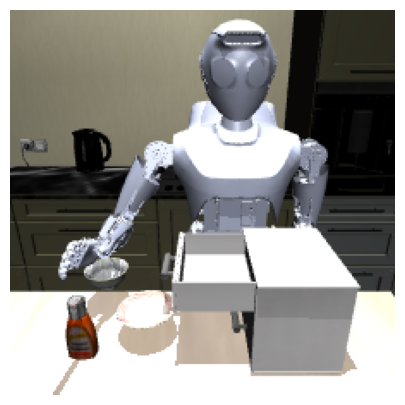

In [3]:
# LIBERO environment creation + episode presets

from surena_vla.integrations import register_all
register_all()

from libero.libero.envs.bddl_base_domain import TASK_MAPPING
import surena_vla.integrations.libero.surena_manipulation as sm

importlib.reload(sm)

for k in list(TASK_MAPPING.keys()):
    if "surena" in k.lower():
        TASK_MAPPING.pop(k)

sm.register_surena_tasks(TASK_MAPPING)

joint_pos_config = {
    "type": "JOINT_POSITION",
    "interpolation": None,
    "ramp_ratio": 0.2,
    "input_max": 1, 
    "input_min": -1,
    "output_max": 1.0, 
    "output_min": -1.0,
    "kp": 200, 
    "damping_ratio": 1,
    "impedance_mode": "fixed",
    "kp_limits": [0, 300], 
    "damping_ratio_limits": [0, 15],
    "position_limits": None, 
    "velocity_limits": None,
}

AVAILABLE_TASKS = sm.list_presets(verbose=False)

TASK_PRESET = "close_top_drawer"
# TASK_PRESET = "open_top_drawer"
# TASK_PRESET = "close_bottom_drawer"
# TASK_PRESET = "put_black_bowl_on_plate"
# TASK_PRESET = "put_ketchup_in_top_drawer"
# TASK_PRESET = "put_black_bowl_in_top_drawer"
# TASK_PRESET = "put_frying_pan_on_stove"
# TASK_PRESET = "put_moka_pot_on_stove"
# TASK_PRESET = "turn_on_stove"
# TASK_PRESET = "close_microwave"
# TASK_PRESET = "open_microwave"
# TASK_PRESET = "put_middle_black_bowl_on_plate"
# TASK_PRESET = "stack_middle_bowl_on_back_bowl"
# TASK_PRESET = "put_book_in_left_caddy"
# TASK_PRESET = "put_book_on_shelf"

cfg = sm.get_preset(TASK_PRESET)

# notebook-side overrides
cfg.update({
    # "max_vla_steps": 125,
    # "pos_scale": 0.035,
    # "rot_scale": 0.005,
    # "max_rot_delta": 0.020,
    # "sticky": False,
    # "sticky_attach_distance": 0.05,
    # "success_delta": 0.12,
    "use_native_success": False,
})


if "env" in globals():
    try:
        env.close()
    except Exception:
        pass

env, instruction = sm.make_env(
    TASK_PRESET,
    controller_configs=joint_pos_config,
    has_renderer=False,
    has_offscreen_renderer=True,
    use_camera_obs=True,
    camera_names=["agentview"],
    camera_heights=224,
    camera_widths=224,
    control_freq=20,
    horizon=max(500, int(cfg.get("max_vla_steps", 125)) * 50),
    reward_shaping=False,
    debug_reachability=False,
    warn_missing_scene_elements=False,
    use_libero_success_first=True,
)

obs = env.reset()


print("TASK_PRESET:", TASK_PRESET)
print("Instruction for VLA:", repr(instruction))
print("mode:", cfg["mode"])
print("max_vla_steps:", cfg.get("max_vla_steps"))
print("pos_scale:", cfg.get("pos_scale"))
print("rot_scale:", cfg.get("rot_scale"))
print("sticky:", cfg.get("sticky"))
print("sticky_attach_distance:", cfg.get("sticky_attach_distance"))
print("robot0_eef_pos:", np.round(obs["robot0_eef_pos"], 4))
print("action_dim:", env.action_dim)


plt.figure(figsize=(8, 5))
img = render_frame(env, camera_name="agentview")
plt.imshow(img)
plt.axis("off")
plt.show()

## 4. Controller preparation

In [4]:
# Create / rebind controller and apply the recommended dynamic execution settings

def prepare_surena_controller(
    env,
    ctrl=None,
    *,
    settle_steps=50,
    pos_scale=0.035,
    rot_scale=0.003,
    max_rot_delta=0.01,
    sticky=False,
    sticky_attach_distance=HONEST_STICKY_ATTACH_DISTANCE,
    verbose=True,
):
    obs, ctrl = reset_settle_rebind(env, ctrl=ctrl, settle_steps=settle_steps)

    ctrl.configure_vla_execution(
        kp_major=1200.0,
        kp_wrist=600.0,
        damping_major=45.0,
        damping_wrist=25.0,
        gravity_comp=True,
        gravity_strength=1.0,
        verbose=verbose,
    )

    ctrl.vla.pos_scale = float(pos_scale)
    ctrl.vla.rot_scale = float(rot_scale)
    ctrl.vla.MAX_ROT_DELTA = float(max_rot_delta)
    ctrl.reset_vla()

    if sticky:
        # No object_name_filter here. The palm may attach to the nearest freejoint
        # object only when the gripper command is explicitly > 0.5.
        ctrl.enable_sticky_gripper(
            env=env,
            object_name_filter=None,
            attach_distance=sticky_attach_distance,
            close_threshold=0.5,
            release_threshold=0.5,
            verbose=False,
        )
    else:
        ctrl.disable_sticky_gripper()

    p, _ = ctrl.get_eef_pose()
    print("\nController ready.")
    print("EEF:", np.round(p, 6))
    print("pos_scale:", ctrl.vla.pos_scale)
    print("rot_scale:", ctrl.vla.rot_scale)
    print("sticky:", ctrl.sticky is not None)

    if ctrl.sticky is not None:
        print("sticky attach_distance:", ctrl.sticky.attach_distance)
        print("nearest freejoint candidates:")
        ctrl.print_gripper_candidates(max_rows=12)

    return obs, ctrl

## 5. Centralized VLA utilities

Live view, VLA inference, raw MuJoCo access, sticky-state logging, and ...

In [5]:
# Centralized VLA episode utilities

try:
    import cv2
except Exception:
    cv2 = None

import types


def show_live_frame(frame, lines=None, window_name="Surena VLA live", enabled=True):
    if not enabled:
        return True

    if cv2 is None:
        try:
            env.render()
        except Exception:
            pass
        return True

    img = np.asarray(frame).copy()
    if img.dtype != np.uint8:
        img = np.clip(img, 0, 255).astype(np.uint8)

    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    if lines:
        y = 22
        for line in lines:
            cv2.putText(
                img,
                str(line),
                (8, y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.48,
                (255, 255, 255),
                1,
                cv2.LINE_AA,
            )
            y += 20

    cv2.imshow(window_name, img)
    key = cv2.waitKey(1)
    return key != 27


def close_live_viewer():
    if cv2 is not None:
        try:
            cv2.destroyAllWindows()
        except Exception:
            pass


def get_raw_model_data(env):
    model = env.sim.model._model if hasattr(env.sim.model, "_model") else env.sim.model
    data = env.sim.data._data if hasattr(env.sim.data, "_data") else env.sim.data
    return model, data


def predict_vla_action(frame, instruction):
    if "vla" not in globals():
        raise RuntimeError("Load the VLA model first.")

    image = Image.fromarray(np.asarray(frame).astype(np.uint8))

    with torch.no_grad():
        action = vla.predict_action(
            image=image,
            instruction=instruction,
            unnorm_key=VLA_UNNORM_KEY,
            do_sample=False,
        )

    return np.asarray(action, dtype=float)

def sticky_state(ctrl):
    if getattr(ctrl, "sticky", None) is None:
        return {"attached": False, "body_name": None}

    return {
        "attached": bool(ctrl.sticky.attached),
        "body_name": ctrl.sticky.attached_body_name,
    }

## 6. General episode runners

The important rule is simple: task differences live in `cfg` and in small action / success adapters. The main loop stays shared.

### 6.1 Episode configuration and success monitoring

In [6]:
# Episode runner configuration + success monitoring

RUNNER_DEFAULTS = {
    "ctrl_ticks_per_vla_action": 35,
    "render_stride": 8,
    "verbose_every": 1,
    "soft_ik_warn_err": 0.055,
    "hard_ik_stop_err": 0.120,
    "rot_fraction_drawer": 0.50,
    "rot_fraction_articulation": 0.50,
    "rot_fraction_pick_place": 0.50,
    "grip_close_threshold": 0.50,
}


def resolve_episode_cfg(cfg_or_name=None):
    """Return a fresh notebook-side episode config dict."""
    if cfg_or_name is None:
        if "cfg" not in globals():
            raise RuntimeError("No cfg found. Run the LIBERO task environment creation cell first.")
        cfg_or_name = cfg

    if isinstance(cfg_or_name, str):
        out = sm.get_preset(cfg_or_name)
    else:
        out = dict(cfg_or_name)

    if "preset_name" not in out and "TASK_PRESET" in globals():
        out["preset_name"] = TASK_PRESET

    mode = out.get("mode", "pick_place")
    if mode not in {"drawer", "articulation", "pick_place", "combo", "drawer_sequence"}:
        raise ValueError(f"Unsupported episode mode: {mode!r}")

    for key, value in RUNNER_DEFAULTS.items():
        out.setdefault(key, value)

    out.setdefault("instruction", globals().get("instruction", ""))
    out.setdefault("max_vla_steps", 125)
    out.setdefault("pos_scale", 0.035)
    out.setdefault("rot_scale", 0.005)
    out.setdefault("max_rot_delta", 0.020)
    out.setdefault("sticky", mode in {"pick_place", "combo"})
    out.setdefault("sticky_attach_distance", HONEST_STICKY_ATTACH_DISTANCE)
    return out


def apply_episode_control_cfg(ctrl, cfg):
    """Apply VLA integration scales to the already prepared controller."""
    ctrl.vla.pos_scale = float(cfg["pos_scale"])
    ctrl.vla.rot_scale = float(cfg["rot_scale"])
    ctrl.vla.MAX_ROT_DELTA = float(cfg["max_rot_delta"])
    return ctrl


def configure_sticky_for_episode(env, ctrl, cfg):
    """Enable sticky only for modes/configs that explicitly need grasping."""
    if bool(cfg.get("sticky", False)):
        ctrl.enable_sticky_gripper(
            env=env,
            object_name_filter=cfg.get("object_name_filter", None),
            attach_distance=float(cfg.get("sticky_attach_distance", HONEST_STICKY_ATTACH_DISTANCE)),
            close_threshold=float(cfg.get("grip_close_threshold", 0.5)),
            release_threshold=float(cfg.get("grip_close_threshold", 0.5)),
            verbose=False,
        )
        print("sticky=True")
        print("object_name_filter:", cfg.get("object_name_filter", None))
        print("sticky attach_distance:", ctrl.sticky.attach_distance)
        print("nearest freejoint candidates:")
        ctrl.print_gripper_candidates(max_rows=12)
    else:
        ctrl.disable_sticky_gripper()
        print("sticky=False")


def _resolve_mujoco_name(model, candidates, kind):
    if isinstance(candidates, str):
        candidates = [candidates]
    obj_type = {
        "joint": mujoco.mjtObj.mjOBJ_JOINT,
        "body": mujoco.mjtObj.mjOBJ_BODY,
        "site": mujoco.mjtObj.mjOBJ_SITE,
    }[kind]
    for name in candidates:
        if mujoco.mj_name2id(model, obj_type, name) >= 0:
            return name
    return None


def _collect_scalar_success_specs(spec):
    """Collect drawer/articulation specs from SUCCESS_SPEC, including nested all/any."""
    if not spec:
        return []
    typ = spec.get("type")
    if typ in {"drawer", "articulation"}:
        return [spec]
    if typ in {"all", "any"}:
        out = []
        for item in spec.get("items", []):
            out.extend(_collect_scalar_success_specs(item))
        return out
    return []


def make_episode_success_monitor(env, cfg):
    """
    General success monitor.

    Primary signal: env._check_success(), which is implemented in surena_manipulation.
    Extra logging: scalar joint progress for drawer / articulation tasks.
    """
    model, data = get_raw_model_data(env)
    success_spec = getattr(env, "SUCCESS_SPEC", None)
    scalar_specs = _collect_scalar_success_specs(success_spec)

    joint_rows = []
    for spec in scalar_specs:
        name = _resolve_mujoco_name(model, spec.get("joint_names", []), "joint")
        if name is None:
            continue
        jid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, name)
        qadr = int(model.jnt_qposadr[jid])
        joint_rows.append({
            "name": name,
            "qadr": qadr,
            "type": spec.get("type"),
            "target": spec.get("target"),
            "q0": float(data.qpos[qadr]),
        })

    if joint_rows:
        print("[Success monitor] scalar joints:")
        for r in joint_rows:
            print(f"  {r['name']} | q0={r['q0']:+.4f} | target={r['target']}")
    else:
        print("[Success monitor] using env._check_success() only")

    def check(verbose=False):
        _, data_now = get_raw_model_data(env)


        # try:
        #     native_success = bool(env._check_success())
        # except Exception as exc:
        #     native_success = False
        #     native_error = repr(exc)
        # else:
        #     native_error = None

        use_native_success = bool(cfg.get("use_native_success", cfg.get("mode") not in {"drawer", "articulation"}))
        try:
            native_success = bool(env._check_success()) if use_native_success else False
        except Exception as exc:
            native_success = False
            native_error = repr(exc)
        else:
            native_error = None


        joint_info = []
        for r in joint_rows:
            q = float(data_now.qpos[r["qadr"]])
            delta = q - r["q0"]
            target = r["target"]

            # These thresholds match the local success logic in surena_manipulation.
            
            # target_met = False
            # if r["type"] == "drawer":
            #     if target == "open":
            #         target_met = q <= -0.08
            #     elif target == "closed":
            #         target_met = q >= -0.04
            # elif r["type"] == "articulation":
            #     if target == "on":
            #         target_met = q >= 0.45
            #     elif target == "off":
            #         target_met = q <= 0.25
            #     elif target == "open":
            #         target_met = q <= -0.50
            #     elif target == "closed":
            #         target_met = q >= -0.25

            target_met = False
            success_delta = cfg.get("success_delta", None)

            if r["type"] == "drawer":
                if success_delta is not None:
                    success_delta = abs(float(success_delta))
                    if target == "closed":
                        # Drawer closing means q moves upward toward 0.
                        target_met = delta >= success_delta
                    elif target == "open":
                        # Drawer opening means q moves downward / more negative.
                        target_met = -delta >= success_delta
                else:
                    # Fallback to surena_manipulation thresholds.
                    if target == "open":
                        target_met = q <= -0.08
                    elif target == "closed":
                        target_met = q >= -0.04
            elif r["type"] == "articulation":
                if target == "on":
                    target_met = q >= float(cfg.get("success_q_on", 0.45))
                elif target == "off":
                    target_met = q <= float(cfg.get("success_q_off", 0.25))
                elif target == "open":
                    target_met = q <= float(cfg.get("success_q_open", -0.50))
                elif target == "closed":
                    target_met = q >= float(cfg.get("success_q_closed", -0.25))
                    


            joint_info.append({
                "name": r["name"],
                "q": q,
                "q0": r["q0"],
                "delta": delta,
                "target": target,
                "target_met": bool(target_met),
            })

        scalar_success = bool(joint_info) and all(item["target_met"] for item in joint_info)
        success = bool(native_success or scalar_success)
        info = {
            "success": success,
            "native_success": native_success,
            "native_error": native_error,
            "scalar_success": scalar_success,
            "joints": joint_info,
        }

        if verbose:
            if joint_info:
                best = max(joint_info, key=lambda x: abs(x["delta"]))
                print(
                    f"[success] {success} | native={native_success} | "
                    f"joint={best['name']} | q0={best['q0']:+.4f} | "
                    f"q={best['q']:+.4f} | delta={best['delta']:+.4f} | "
                    f"target={best['target']} | target_met={best['target_met']}"
                )
            else:
                print(f"[success] {success} | native={native_success}")

        return success, info

    return check


### 6.2 Action adapters

In [7]:
# General VLA action adapter

def transform_vla_action(ctrl, raw_action, cfg):
    """
    Convert raw VLA action to executable Surena action.

    This is the only place where task-mode behavior should differ:
      - drawer / articulation: no sticky, force gripper open
      - pick_place / combo: strict sticky gripper threshold
      - rotation authority is mode-specific but still configurable from cfg
    """
    raw = np.asarray(raw_action, dtype=float).copy()
    if raw.shape[0] < 7:
        raise ValueError(f"VLA action must have at least 7 values, got shape {raw.shape}")

    mode = cfg.get("mode", "pick_place")
    exec_action = raw.copy()

    if mode == "drawer":
        rot_fraction = float(cfg.get("rot_fraction", cfg["rot_fraction_drawer"]))
        exec_action[3:6] = rot_fraction * np.clip(exec_action[3:6], -1.0, 1.0)
        exec_action[6] = 0.0
    elif mode == "articulation":
        rot_fraction = float(cfg.get("rot_fraction", cfg["rot_fraction_articulation"]))
        exec_action[3:6] = rot_fraction * np.clip(exec_action[3:6], -1.0, 1.0)
        exec_action[6] = 0.0
    elif mode in {"pick_place", "combo"}:
        rot_fraction = float(cfg.get("rot_fraction", cfg["rot_fraction_pick_place"]))
        exec_action[3:6] = rot_fraction * np.clip(exec_action[3:6], -0.5, 0.5)
        threshold = float(cfg.get("grip_close_threshold", 0.5))
        exec_action[6] = 1.0 if float(raw[6]) > threshold else 0.0
    else:
        raise ValueError(f"No action adapter for mode={mode!r}")

    dpos_cmd = np.clip(
        exec_action[:3] * ctrl.vla.pos_scale,
        -ctrl.vla.MAX_POS_DELTA,
        ctrl.vla.MAX_POS_DELTA,
    )

    return exec_action, dpos_cmd


def episode_overlay_lines(cfg, step, raw_action=None, exec_action=None, ctrl=None, ik_info=None):
    lines = [
        f"step={step}",
        # f"mode={cfg.get('mode')}",
        # f"preset={cfg.get('preset_name', TASK_PRESET if 'TASK_PRESET' in globals() else '')}",
    ]

    if raw_action is not None and exec_action is not None:
        lines.append(f"raw_grip={float(raw_action[6]):+.3f} exec_grip={float(exec_action[6]):+.1f}")
    if ctrl is not None and bool(cfg.get("sticky", False)):
        lines.append(f"sticky={sticky_state(ctrl)}")
    if ik_info is not None:
        lines.append(f"ik={ik_info.get('status')} pe={ik_info.get('pos_err', np.nan):.3f}")
    return lines


### 6.3 Generic VLA step loop

In [8]:
# Generic VLA loop. This is the runner core.

def run_vla_step_loop(
    env,
    ctrl,
    cfg_or_name=None,
    *,
    show_live=True,
    terminate_on_success=True,
):
    cfg = resolve_episode_cfg(cfg_or_name)
    apply_episode_control_cfg(ctrl, cfg)
    configure_sticky_for_episode(env, ctrl, cfg)
    ctrl.reset_vla()

    success_monitor = make_episode_success_monitor(env, cfg)

    print("\nRunning VLA episode")
    print("preset:", cfg.get("preset_name"))
    print("mode:", cfg.get("mode"))
    print("instruction:", repr(cfg["instruction"]))
    print("max_vla_steps:", cfg["max_vla_steps"])
    print("pos_scale:", ctrl.vla.pos_scale)
    print("rot_scale:", ctrl.vla.rot_scale)
    print("max_rot_delta:", ctrl.vla.MAX_ROT_DELTA)

    frames = []
    raw_actions = []
    exec_actions = []
    ik_log = []
    success_log = []
    sticky_log = []
    eef_log_all = []
    obj_log_all = []

    stop_reason = "max_steps"

    for step in range(int(cfg["max_vla_steps"])):
        frame = render_frame(env, camera_name="agentview")
        frames.append(frame)

        if not show_live_frame(
            frame,
            lines=episode_overlay_lines(cfg, step, ctrl=ctrl),
            enabled=show_live,
        ):
            print("[LIVE] ESC pressed. Stopping.")
            stop_reason = "live_esc"
            break

        raw_action = predict_vla_action(frame, cfg["instruction"])
        exec_action, dpos_cmd = transform_vla_action(ctrl, raw_action, cfg)

        raw_actions.append(raw_action.copy())
        exec_actions.append(exec_action.copy())

        pos_before, _ = ctrl.get_eef_pose()
        use_sticky = bool(cfg.get("sticky", False))

        ik_info = ctrl.apply_vla_action(
            exec_action,
            verbose=False,
            update_sticky=use_sticky,
            n_random_seeds=int(cfg.get("n_random_seeds", 8)),
            seed_std=float(cfg.get("seed_std", 0.35)),
            max_reach=float(cfg.get("ik_max_reach", IK_MAX_REACH)),
        )
        ik_log.append(ik_info)

        if ik_info["pos_err"] > float(cfg["soft_ik_warn_err"]):
            print(
                f"[IK WARN] step={step} | "
                f"pe={ik_info['pos_err']:.4f} | status={ik_info['status']}"
            )

        if ik_info["pos_err"] > float(cfg["hard_ik_stop_err"]):
            print(
                f"[HARD STOP] step={step} | "
                f"pe={ik_info['pos_err']:.4f} | status={ik_info['status']}"
            )
            stop_reason = "hard_ik_stop"
            break

        gripper_action = float(exec_action[6]) if use_sticky else None
        step_out = execute_joint_target(
            env,
            ctrl,
            ik_info["q_goal"],
            ctrl_ticks=int(cfg["ctrl_ticks_per_vla_action"]),
            record=True,
            render_stride=int(cfg["render_stride"]),
            camera_name="agentview",
            gripper_action=gripper_action,
        )

        step_frames = step_out[0]
        eef_log = step_out[1]
        obj_log = step_out[2] if use_sticky and len(step_out) > 2 else None

        frames.extend(step_frames)
        eef_log_all.extend(list(eef_log))
        if obj_log is not None:
            obj_log_all.extend(list(obj_log))

        live_stop = False
        for f in step_frames:
            if not show_live_frame(
                f,
                lines=episode_overlay_lines(cfg, step, raw_action, exec_action, ctrl, ik_info),
                enabled=show_live,
            ):
                print("[LIVE] ESC pressed. Stopping.")
                live_stop = True
                break
        if live_stop:
            stop_reason = "live_esc"
            break

        pos_after, _ = ctrl.get_eef_pose()
        dpos_act = pos_after - pos_before

        success, success_info = success_monitor(
            verbose=(step % int(cfg["verbose_every"]) == 0)
        )
        success_log.append(success_info)
        sticky_log.append(sticky_state(ctrl))

        if step % int(cfg["verbose_every"]) == 0:
            print(
                f"step {step:03d} | "
                f"dpos_cmd={np.round(dpos_cmd, 4)} | "
                f"dpos_act={np.round(dpos_act, 4)} | "
                f"raw_grip={raw_action[6]:+.3f} | "
                f"exec_grip={exec_action[6]:+.1f} | "
                f"sticky={sticky_state(ctrl)} | "
                f"ik={ik_info['status']} | "
                f"pe={ik_info['pos_err']:.4f} | "
                f"re={ik_info['rot_err']:.4f} | "
                f"success={success}"
            )

        if terminate_on_success and success:
            print(f"[SUCCESS] step={step} | preset={cfg.get('preset_name')} | mode={cfg.get('mode')}")
            stop_reason = "success"
            break

    return {
        "preset_name": cfg.get("preset_name"),
        "mode": cfg.get("mode"),
        "instruction": cfg.get("instruction"),
        "cfg": cfg,
        "frames": frames,
        "raw_actions": np.asarray(raw_actions),
        "exec_actions": np.asarray(exec_actions),
        "ik_log": ik_log,
        "success_log": success_log,
        "sticky_log": sticky_log,
        "eef_log": np.asarray(eef_log_all),
        "obj_log": np.asarray(obj_log_all) if obj_log_all else None,
        "stop_reason": stop_reason,
        "ctrl": ctrl,
    }


### 6.4 Public runner entry point

In [9]:
# Public entry point for all task modes.

def run_surena_vla_episode(
    env,
    ctrl,
    cfg_or_name=None,
    *,
    show_live=True,
    terminate_on_success=True,
):
    """
    Execute one Surena × LIBERO VLA episode.

    Use this for drawer, articulation, and pick-place tasks.
    To add a new runner behavior, add a tiny branch in transform_vla_action()
    or a richer monitor in make_episode_success_monitor(); do not fork this loop.
    """
    cfg_local = resolve_episode_cfg(cfg_or_name)

    if cfg_local.get("mode") == "drawer_sequence":
        raise NotImplementedError(
            "drawer_sequence should be expressed as multiple normal presets/subtasks. "
            "The current surena_manipulation catalog exposes single-task presets."
        )

    return run_vla_step_loop(
        env,
        ctrl,
        cfg_local,
        show_live=show_live,
        terminate_on_success=terminate_on_success,
    )


## 7. Full VLA episode

In [10]:
# Full VLA episode execution cell
# Assumes: setup, VLA loading, environment creation, controller preparation, and runner cells are already run.

SHOW_LIVE = True
TERMINATE_ON_SUCCESS = True

if "env" not in globals():
    raise RuntimeError("Create the LIBERO env manually before running this cell.")
if "TASK_PRESET" not in globals():
    raise RuntimeError("Set TASK_PRESET before running this cell.")
if "cfg" not in globals():
    cfg = sm.get_preset(TASK_PRESET)

cfg = resolve_episode_cfg(cfg)

print("Running preset:", TASK_PRESET)
print("Instruction:", cfg["instruction"])
print("Mode:", cfg["mode"])
print("Expected env class:", cfg.get("env_class"))

obs, ctrl = prepare_surena_controller(
    env,
    ctrl=globals().get("ctrl", None),
    pos_scale=cfg["pos_scale"],
    rot_scale=cfg["rot_scale"],
    max_rot_delta=cfg["max_rot_delta"],
    sticky=False,  # runner enables sticky only after it resets VLA and reads cfg
    sticky_attach_distance=cfg.get("sticky_attach_distance", HONEST_STICKY_ATTACH_DISTANCE),
    verbose=False,
)

t0 = time.time()
episode = None

try:
    episode = run_surena_vla_episode(
        env,
        ctrl,
        cfg,
        show_live=SHOW_LIVE,
        terminate_on_success=TERMINATE_ON_SUCCESS,
    )
finally:
    close_live_viewer()

elapsed = time.time() - t0

print("\nEpisode complete.")
print("preset:", TASK_PRESET)
print("mode:", episode["mode"])
print("stop_reason:", episode["stop_reason"])
print("frames:", len(episode["frames"]))
print("elapsed:", f"{elapsed:.1f} s")

if episode.get("ik_log"):
    print(f"IK exact-ok rate: {100 * np.mean([r.get('ok', False) for r in episode['ik_log']]):.1f}%")
    print(f"Mean pos err: {np.mean([r['pos_err'] for r in episode['ik_log']]):.6f} m")
    print(f"Max pos err:  {np.max([r['pos_err'] for r in episode['ik_log']]):.6f} m")

if episode.get("success_log"):
    print("final success:", bool(episode["success_log"][-1].get("success", False)))

# display(make_rgb_animation(episode["frames"], fps=20, title=TASK_PRESET, max_frames=400))

Running preset: close_top_drawer
Instruction: close the top drawer of the cabinet
Mode: drawer
Expected env class: <class 'surena_vla.integrations.libero.surena_manipulation.SurenaCloseTopDrawer'>
[VLA] Reset to current EEF pose: [-0.3207 -0.2092  1.1232]
[VLA] Reset to current EEF pose: [-0.3207 -0.2092  1.1232]

Controller ready.
EEF: [-0.32074  -0.209176  1.123201]
pos_scale: 0.035
rot_scale: 0.004
sticky: False
sticky=False
[VLA] Reset to current EEF pose: [-0.3207 -0.2092  1.1232]
[Success monitor] scalar joints:
  white_cabinet_1_top_level | q0=-0.1600 | target=closed

Running VLA episode
preset: close_top_drawer
mode: drawer
instruction: 'close the top drawer of the cabinet'
max_vla_steps: 75
pos_scale: 0.035
rot_scale: 0.004
max_rot_delta: 0.01
[success] False | native=False | joint=white_cabinet_1_top_level | q0=-0.1600 | q=-0.1600 | delta=+0.0000 | target=closed | target_met=False
step 000 | dpos_cmd=[-0.      0.0205 -0.0028] | dpos_act=[-0.      0.0206 -0.0028] | raw_grip=+0

## 8. Save video

In [11]:
# Save the latest episode video
if "episode" not in globals() or episode is None:
    raise RuntimeError("Run the full VLA episode cell first.")
if len(episode["frames"]) == 0:
    raise RuntimeError("Episode has no frames to save.")

video_path = save_episode_video(
    frames=episode["frames"],
    out_path=VIDEOS_ROOT / f"{TASK_PRESET}_{time.strftime('%Y%m%d_%H%M%S')}.mp4",
    fps=60,
)

Saved video: /home/parsa/surena-vla-ws/surena-vla-manipulation/outputs/videos/close_top_drawer_20260713_161237.mp4
Frames: 2288 | fps: 60 | duration: 38.1 s


In [12]:
# Cell — Visualize Episode Like OpenVLA Action-History Demo

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display


def show_episode_action_history(
    episode,
    task_name=None,
    *,
    action_kind="exec",     # "exec" or "raw"
    fps=8,
    max_steps=None,
    use_fixed_colors=True,
):


    frames = episode.get("frames", [])
    if len(frames) == 0:
        raise ValueError("episode['frames'] is empty.")

    if action_kind == "raw":
        actions = np.asarray(episode.get("raw_actions", []), dtype=float)
        action_title = "Raw Action History"
    elif action_kind == "exec":
        actions = np.asarray(episode.get("exec_actions", []), dtype=float)
        action_title = "Action History"
    else:
        raise ValueError("action_kind must be 'raw' or 'exec'.")

    if actions.ndim != 2 or actions.shape[1] < 7:
        raise ValueError(f"Expected action array with shape (N, 7+), got {actions.shape}")

    actions = actions[:, :7]

    n_steps = len(actions)
    if max_steps is not None:
        n_steps = min(n_steps, int(max_steps))
        actions = actions[:n_steps]

    if n_steps <= 0:
        raise ValueError("No actions to animate.")

    # Map VLA action steps to representative rendered frames.
    # Your episode usually has thousands of frames but tens of VLA decisions.
    frame_ids = np.linspace(0, len(frames) - 1, n_steps, dtype=int)
    step_frames = [frames[i] for i in frame_ids]

    labels = ["dx", "dy", "dz", "droll", "dpitch", "dyaw", "gripper"]

    # Same kind of colors as your example image.
    colors = [
        "#e74c3c",  # dx
        "#2ecc71",  # dy
        "#3498db",  # dz
        "#f39c12",  # droll
        "#9b59b6",  # dpitch
        "#1abc9c",  # dyaw
        "#34495e",  # gripper
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ------------------------------------------------------------------
    # Left panel: simulation frame
    # ------------------------------------------------------------------
    im = axes[0].imshow(step_frames[0])
    axes[0].set_title(f'"{task_name or episode.get("instruction", episode.get("preset_name", "episode"))}"')
    axes[0].axis("off")

    step_text = axes[0].text(
        5,
        15,
        "",
        color="white",
        fontsize=10,
        bbox=dict(facecolor="black", alpha=0.55),
    )

    # ------------------------------------------------------------------
    # Right panel: action history
    # ------------------------------------------------------------------
    lines = []
    for j, lab in enumerate(labels):
        if use_fixed_colors:
            line, = axes[1].plot(
                [],
                [],
                label=lab,
                color=colors[j],
                linewidth=1.5,
            )
        else:
            line, = axes[1].plot(
                [],
                [],
                label=lab,
                linewidth=1.5,
            )
        lines.append(line)

    y_min = float(np.nanmin(actions))
    y_max = float(np.nanmax(actions))
    y_pad = max(0.1, 0.05 * (y_max - y_min + 1e-9))

    axes[1].set_xlim(0, max(1, n_steps - 1))
    axes[1].set_ylim(y_min - y_pad, y_max + y_pad)
    axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
    axes[1].legend(fontsize=7, loc="upper right")
    axes[1].set_title(action_title)
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Value")

    def update(step_idx):
        im.set_data(step_frames[step_idx])

        step_text.set_text(
            f"Step {step_idx + 1}/{n_steps}"
        )

        x = np.arange(step_idx + 1)

        for j, line in enumerate(lines):
            line.set_data(x, actions[:step_idx + 1, j])

        return [im, step_text] + lines

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=n_steps,
        interval=int(1000 / fps),
        blit=True,
    )

    plt.tight_layout()
    plt.close(fig)

    return HTML(anim.to_jshtml())


display(show_episode_action_history(
    episode,
    task_name=cfg.get("instruction", TASK_PRESET),
    action_kind="exec",   # use "raw" if you want model output before notebook modifications
    fps=8,
))

07/13 [16:14:06] INFO     | >> Animation.save using <class 'matplotlib.animation.HTMLWriter'>     animation.py:1088

## 9. Cleanup

In [ ]:
# Cleanup
try:
    close_live_viewer()
except Exception:
    pass

try:
    env.close()
    print("Environment closed.")
except Exception as e:
    print("No environment to close or close failed:", e)